In [43]:
import pandas as pd
import matplotlib.pyplot as plt

In [44]:
acl_df = pd.read_csv("../data/processed/acl_analysis.csv")

acl_df["date_ami"] = pd.to_datetime(acl_df["date_ami"])

In [45]:
visit_counts = acl_df["last_name"].value_counts()

visit_counts.describe()

count    73.000000
mean      5.890411
std       3.907122
min       1.000000
25%       2.000000
50%       5.000000
75%       9.000000
max      17.000000
Name: count, dtype: float64

In [46]:
print("Number of patients:", acl_df["last_name"].nunique())
print("Total observations:", len(acl_df))
print("Average visits:", visit_counts.mean())

Number of patients: 73
Total observations: 430
Average visits: 5.890410958904109


In [47]:
visit_counts.head(10)

last_name
Smith           17
Micklewright    14
Forgash         13
Kutsmeda        13
Ent             12
Pucci           11
Wilmot          11
Iorio           10
Karnik          10
McClelland      10
Name: count, dtype: int64

In [48]:
patient = (
    acl_df[
        acl_df["last_name"] == "Kutsmeda"
    ]
    .sort_values("date_ami")
)

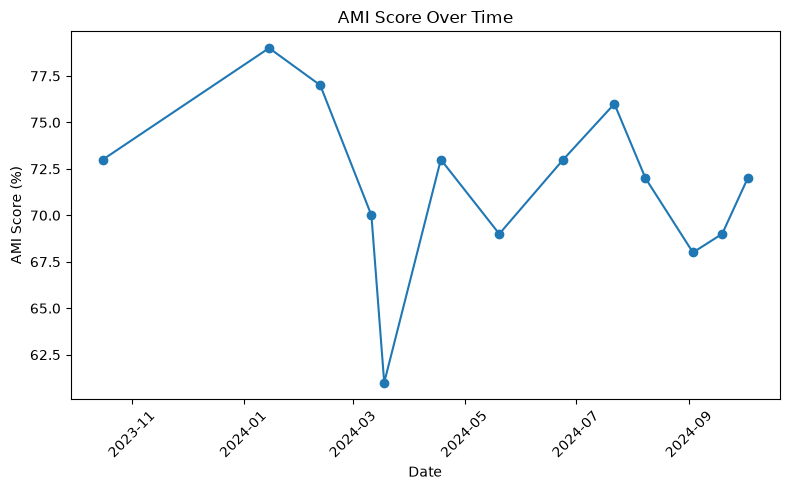

In [49]:
plt.figure(figsize=(8,5))

plt.plot(
    patient["date_ami"],
    patient["score_pct"],
    marker="o"
)

plt.title("AMI Score Over Time")
plt.xlabel("Date")
plt.ylabel("AMI Score (%)")

plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

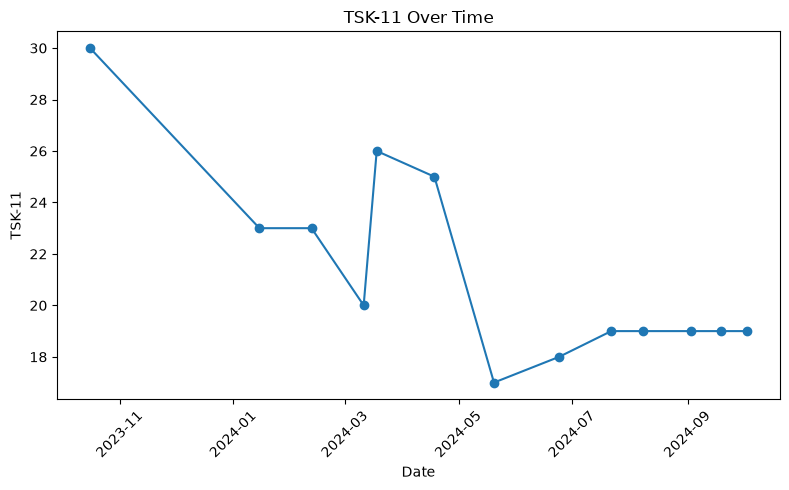

In [50]:
plt.figure(figsize=(8,5))

plt.plot(
    patient["date_ami"],
    patient["tsk_11"],
    marker="o"
)

plt.title("TSK-11 Over Time")
plt.xlabel("Date")
plt.ylabel("TSK-11")

plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

In [51]:
patient = patient.copy()

patient["ami_scaled"] = (
    patient["score_pct"] -
    patient["score_pct"].mean()
) / patient["score_pct"].std()

patient["tsk_scaled"] = (
    patient["tsk_11"] -
    patient["tsk_11"].mean()
) / patient["tsk_11"].std()

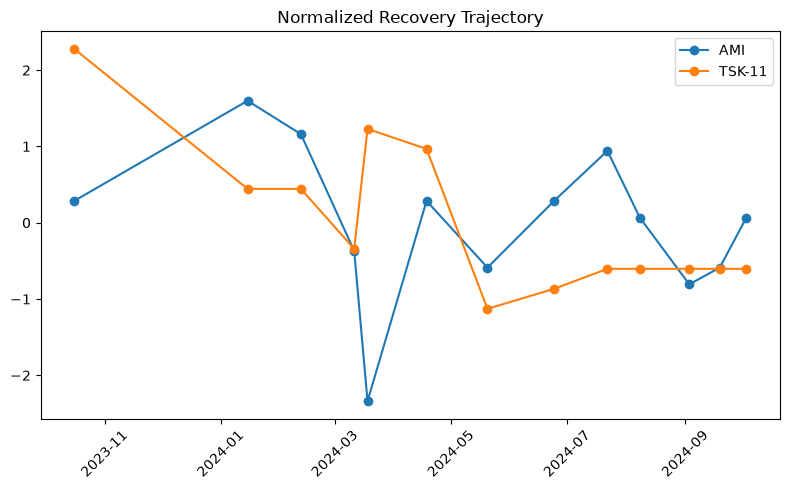

In [52]:
plt.figure(figsize=(8,5))

plt.plot(
    patient["date_ami"],
    patient["ami_scaled"],
    marker="o",
    label="AMI"
)

plt.plot(
    patient["date_ami"],
    patient["tsk_scaled"],
    marker="o",
    label="TSK-11"
)

plt.legend()

plt.title("Normalized Recovery Trajectory")

plt.xticks(rotation=45)

plt.tight_layout()

plt.show()

In [53]:
patient_summary = []

for patient, group in acl_df.groupby("last_name"):

    group = group.sort_values("date_ami")

    if len(group) >= 2:

        patient_summary.append({

            "patient": patient,

            "visits": len(group),

            "ami_change":
                group["score_pct"].iloc[-1]
                - group["score_pct"].iloc[0],

            "tsk_change":
                group["tsk_11"].iloc[-1]
                - group["tsk_11"].iloc[0]

        })

change_df = pd.DataFrame(patient_summary)

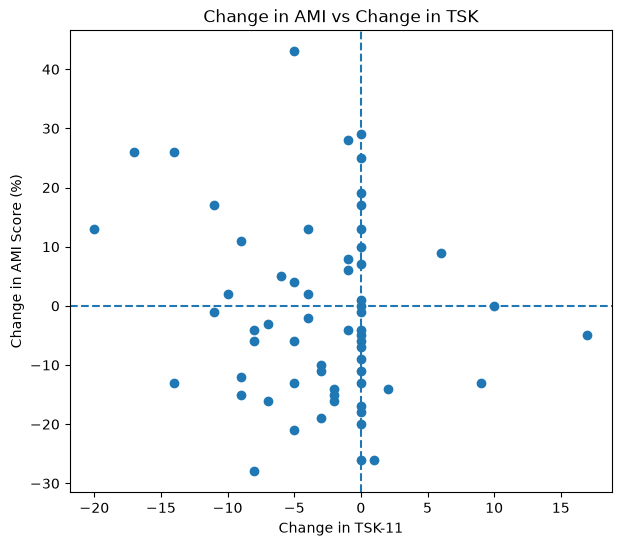

In [54]:
plt.figure(figsize=(7,6))

plt.scatter(
    change_df["tsk_change"],
    change_df["ami_change"]
)

plt.axhline(0, linestyle="--")
plt.axvline(0, linestyle="--")

plt.xlabel("Change in TSK-11")
plt.ylabel("Change in AMI Score (%)")

plt.title("Change in AMI vs Change in TSK")

plt.show()

In [55]:
change_df[
    ["ami_change","tsk_change"]
].corr()

,ami_change,tsk_change
ami_change,1.000000,-0.163736
tsk_change,-0.163736,1.000000
